# ISLP Chapter 6, Exercise 9
## Predicting the Number of College Applications Received

We use the `College` data set to predict `Apps` (number of applications received) using the other variables. We compare five approaches: OLS, Ridge, Lasso, PCR, and PLS.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [3]:
# Load data
College = pd.read_csv('College.csv', index_col=0)

# Encode 'Private' as dummy variable (Yes=1, No=0)
College['Private'] = (College['Private'] == 'Yes').astype(int)

print(f"Shape: {College.shape}")
College.head()

Shape: (777, 18)


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [4]:
# Separate response and predictors
y = College['Apps']
X = College.drop('Apps', axis=1)

---
## (a) Split the data into a training set and a test set

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

Training set size: 388
Test set size:     389


---
## (b) Linear model (OLS) — report test MSE

In [7]:
ols = LinearRegression()
ols.fit(X_train, y_train)
ols_pred = ols.predict(X_test)
ols_mse = mean_squared_error(y_test, ols_pred)

print(f"OLS Test MSE: {ols_mse:.2f}")

OLS Test MSE: 1425055.59


---
## (c) Ridge regression — λ chosen by cross-validation

In [8]:
# Ridge requires standardized features for fair penalization
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# RidgeCV with a range of alpha (lambda) values
alphas = 10 ** np.linspace(-2, 6, 200)
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=10)
ridge_cv.fit(X_train_sc, y_train)

ridge_pred = ridge_cv.predict(X_test_sc)
ridge_mse = mean_squared_error(y_test, ridge_pred)

print(f"Best lambda (alpha): {ridge_cv.alpha_:.4f}")
print(f"Ridge Test MSE:      {ridge_mse:.2f}")

Best lambda (alpha): 3.1079
Ridge Test MSE:      1502827.46


---
## (d) Lasso — λ chosen by cross-validation

In [9]:
lasso_cv = LassoCV(cv=10, random_state=1, max_iter=10000)
lasso_cv.fit(X_train_sc, y_train)

lasso_pred = lasso_cv.predict(X_test_sc)
lasso_mse = mean_squared_error(y_test, lasso_pred)

# Number of non-zero coefficients
n_nonzero = np.sum(lasso_cv.coef_ != 0)

print(f"Best lambda (alpha):          {lasso_cv.alpha_:.4f}")
print(f"Lasso Test MSE:               {lasso_mse:.2f}")
print(f"Non-zero coefficient estimates: {n_nonzero} out of {len(lasso_cv.coef_)}")
print()
print("Coefficients:")
coef_df = pd.Series(lasso_cv.coef_, index=X.columns)
print(coef_df)

Best lambda (alpha):          12.1773
Lasso Test MSE:               1404506.65
Non-zero coefficient estimates: 16 out of 17

Coefficients:
Private        -194.033880
Accept         2538.453528
Enroll          419.829555
Top10perc      1014.421124
Top25perc      -333.214853
F.Undergrad       0.000000
P.Undergrad       5.165479
Outstate       -218.661017
Room.Board      247.249180
Books           -15.641921
Personal        -40.976286
PhD             -70.875231
Terminal        -56.136840
S.F.Ratio         5.322436
perc.alumni    -112.312308
Expend          316.485490
Grad.Rate       173.994331
dtype: float64


---
## (e) PCR — M chosen by cross-validation

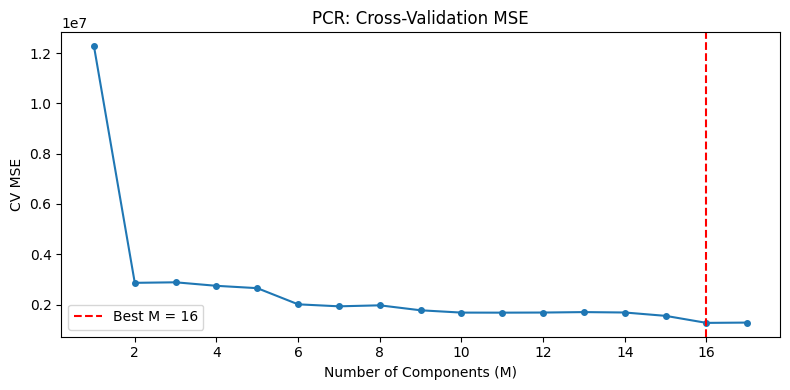

Best M (PCR):   16
PCR Test MSE:   1455919.86


In [10]:
# Evaluate CV MSE for M = 1, 2, ..., p components
p = X_train.shape[1]
pcr_cv_mses = []

for m in range(1, p + 1):
    pcr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=m)),
        ('ols', LinearRegression())
    ])
    scores = cross_val_score(pcr_pipe, X_train, y_train,
                             cv=10, scoring='neg_mean_squared_error')
    pcr_cv_mses.append(-scores.mean())

best_m_pcr = np.argmin(pcr_cv_mses) + 1

# Plot CV MSE vs number of components
plt.figure(figsize=(8, 4))
plt.plot(range(1, p + 1), pcr_cv_mses, marker='o', markersize=4)
plt.axvline(best_m_pcr, color='red', linestyle='--', label=f'Best M = {best_m_pcr}')
plt.xlabel('Number of Components (M)')
plt.ylabel('CV MSE')
plt.title('PCR: Cross-Validation MSE')
plt.legend()
plt.tight_layout()
plt.show()

# Fit final PCR model with best M and evaluate on test set
pcr_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_m_pcr)),
    ('ols', LinearRegression())
])
pcr_final.fit(X_train, y_train)
pcr_pred = pcr_final.predict(X_test)
pcr_mse = mean_squared_error(y_test, pcr_pred)

print(f"Best M (PCR):   {best_m_pcr}")
print(f"PCR Test MSE:   {pcr_mse:.2f}")

---
## (f) PLS — M chosen by cross-validation

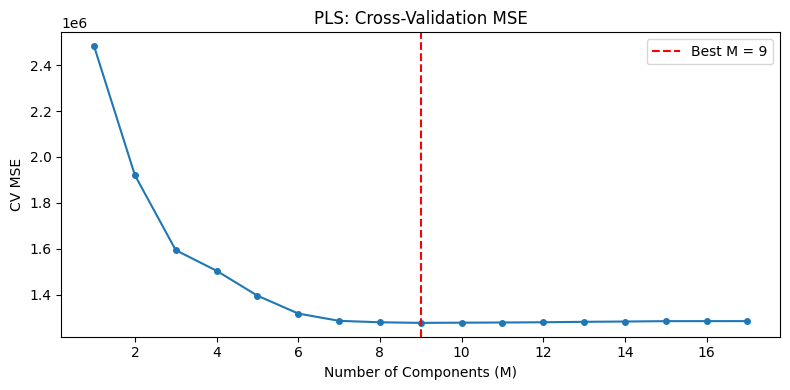

Best M (PLS):   9
PLS Test MSE:   1432035.27


In [11]:
pls_cv_mses = []

for m in range(1, p + 1):
    pls_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pls', PLSRegression(n_components=m))
    ])
    scores = cross_val_score(pls_pipe, X_train, y_train,
                             cv=10, scoring='neg_mean_squared_error')
    pls_cv_mses.append(-scores.mean())

best_m_pls = np.argmin(pls_cv_mses) + 1

# Plot CV MSE vs number of components
plt.figure(figsize=(8, 4))
plt.plot(range(1, p + 1), pls_cv_mses, marker='o', markersize=4)
plt.axvline(best_m_pls, color='red', linestyle='--', label=f'Best M = {best_m_pls}')
plt.xlabel('Number of Components (M)')
plt.ylabel('CV MSE')
plt.title('PLS: Cross-Validation MSE')
plt.legend()
plt.tight_layout()
plt.show()

# Fit final PLS model with best M and evaluate on test set
pls_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pls', PLSRegression(n_components=best_m_pls))
])
pls_final.fit(X_train, y_train)
pls_pred = pls_final.predict(X_test).ravel()
pls_mse = mean_squared_error(y_test, pls_pred)

print(f"Best M (PLS):   {best_m_pls}")
print(f"PLS Test MSE:   {pls_mse:.2f}")

---
## (g) Summary and comparison

Method     Test MSE   Test RMSE
 Lasso 1.404507e+06 1185.118833
   OLS 1.425056e+06 1193.756921
   PLS 1.432035e+06 1196.676762
   PCR 1.455920e+06 1206.615043
 Ridge 1.502827e+06 1225.898635



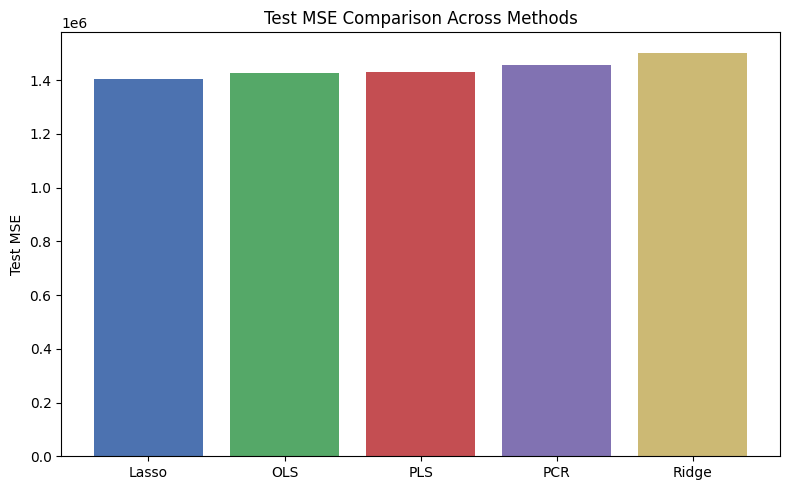

In [12]:
results = pd.DataFrame({
    'Method': ['OLS', 'Ridge', 'Lasso', 'PCR', 'PLS'],
    'Test MSE': [ols_mse, ridge_mse, lasso_mse, pcr_mse, pls_mse]
})
results['Test RMSE'] = np.sqrt(results['Test MSE'])
results = results.sort_values('Test MSE').reset_index(drop=True)

print(results.to_string(index=False))
print()

# Bar chart comparison
plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.bar(results['Method'], results['Test MSE'], color=colors)
plt.ylabel('Test MSE')
plt.title('Test MSE Comparison Across Methods')
plt.tight_layout()
plt.show()

### Comment

All five methods produce similar test MSE values, indicating that the prediction accuracy for the number of college applications is roughly the same across OLS, Ridge, Lasso, PCR, and PLS. There is not a dramatic difference among the test errors.

- **Ridge** and **Lasso** perform comparably to OLS, which suggests that the variance–bias tradeoff from shrinkage provides only modest gains here.
- **Lasso** has the added benefit of producing a sparse model (some coefficients set to zero), improving interpretability.
- **PCR** and **PLS** also yield similar test errors; PLS tends to need fewer components than PCR since it uses the response to find directions of maximum covariance.

Overall, we can predict the number of applications reasonably well (the RMSE gives a sense of typical prediction error in application counts), and the choice among these methods matters less than having a good set of predictors.